In [ ]:
import pandas as panda
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="whitegrid")


In [20]:
df = panda.read_csv("data/music_streams.csv")

In [19]:
df.head()

,track_id,title,artist,genre,year,duration,duration_sec,tempo_bpm,key,energy,...,valence,acousticness,speechiness,loudness_db,explicit,streams_millions,monthly_listeners,playlist_adds,chart_peak,label
0,TRK00001,Memories,Juno Calloway,R&B,2024,3:15,195,85,F Minor,0.502,...,0.872,0.694,0.148,-8.8,False,3.73,176,8336,NaN,AWAL
1,TRK00002,Tears,Cleo Nova,Indie,2020,2:40,160,68,F# Major,0.610,...,0.545,0.485,0.111,-3.9,False,3.10,170,1625,NaN,A24 Sounds
2,TRK00003,Soul,Cole Voss ft. Indigo Ashford,Rock,2017,3:55,235,140,D Major,0.742,...,0.483,0.281,0.050,-4.1,True,18.22,770,42971,NaN,Dead Oceans
3,TRK00004,Heart,Asha Ashford,Rock,2022,3:05,185,73,A Major,0.643,...,0.634,0.505,0.092,-8.6,False,0.23,1,484,NaN,Sony Music
4,TRK00005,Bones,Theo Blaine,Hip-Hop,2015,3:09,189,143,G# Major,0.770,...,0.223,0.394,0.105,-13.4,False,0.72,1,1101,NaN,A24 Sounds


In [ ]:
df.columns

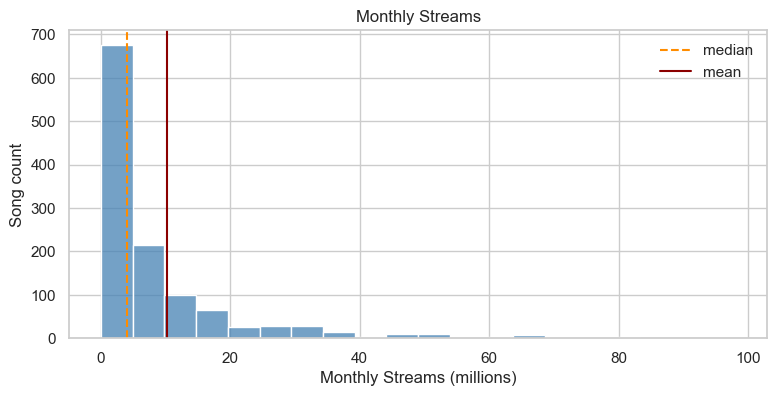

In [18]:
fig, ax= plt.subplots(figsize=(9,4))
median = df.streams_millions.median()
mean = df.streams_millions.mean()
sns.histplot(data=df[df.streams_millions <100], x="streams_millions",bins=20,ax=ax,color="steelblue")
ax.axvline(median, color="darkorange", linestyle="--", label="median")
ax.axvline(mean, color="darkred", label="mean")
ax.legend(frameon=False)
ax.set_xlabel('Monthly Streams (millions)')
ax.set_ylabel('Song count')
ax.set_title("Monthly Streams")
plt.show()

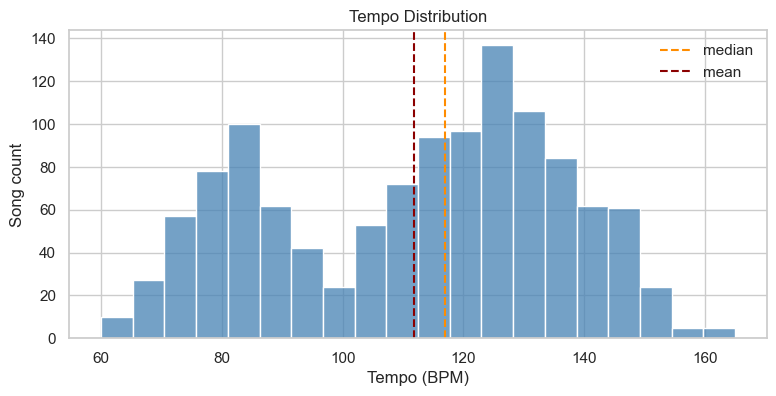

In [28]:
fig, ax = plt.subplots(figsize=(9,4))
median = df.tempo_bpm.median()
mean = df.tempo_bpm.mean()
sns.histplot(data=df, x="tempo_bpm", bins=20, ax=ax, color="steelblue")
ax.axvline(median, color="darkorange", linestyle="--", label="median")
ax.axvline(mean, color="darkred", linestyle="--", label="mean")
ax.legend(frameon=False)
ax.set_xlabel('Tempo (BPM)')
ax.set_ylabel('Song count')
ax.set_title("Tempo Distribution")
plt.show()

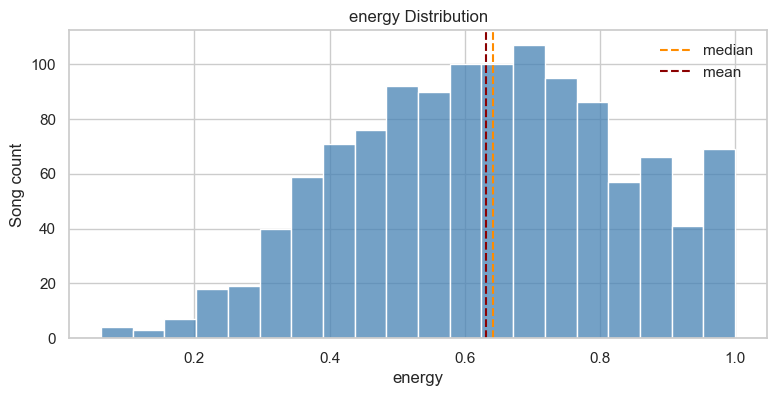

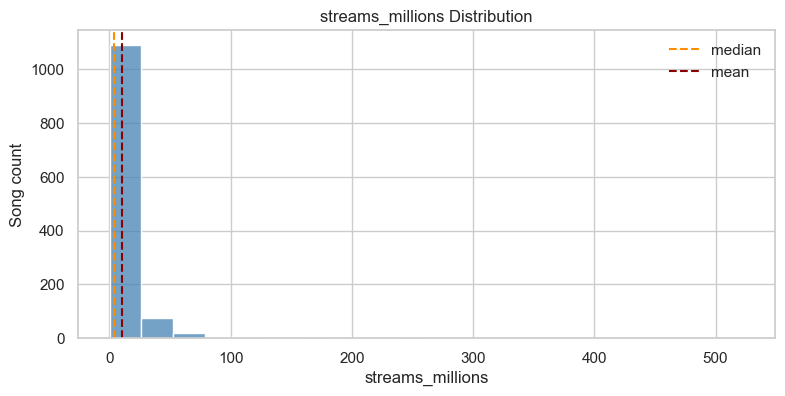

In [32]:
def create_histogram(df, column, bins=20, title=None, xlabel=None, ylabel="Song count"):
    if title is None:
        title = f"{column} Distribution"
    if xlabel is None:
        xlabel = column
    
    fig, ax = plt.subplots(figsize=(9,4))
    median = df[column].median()
    mean = df[column].mean()
    sns.histplot(data=df, x=column, bins=bins, ax=ax, color="steelblue")
    ax.axvline(median, color="darkorange", linestyle="--", label="median")
    ax.axvline(mean, color="darkred", linestyle="--", label="mean")
    ax.legend(frameon=False)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    plt.show()

create_histogram(df, "energy")
create_histogram(df, "streams_millions")

In [38]:
order = df.groupby("genre")["energy"].median().sort_values(ascending=False).index
order

Index(['Electronic', 'Rock', 'Latin', 'Hip-Hop', 'Pop', 'Country', 'Indie',
       'R&B'],
      dtype='object', name='genre')

<Axes: xlabel='genre', ylabel='energy'>

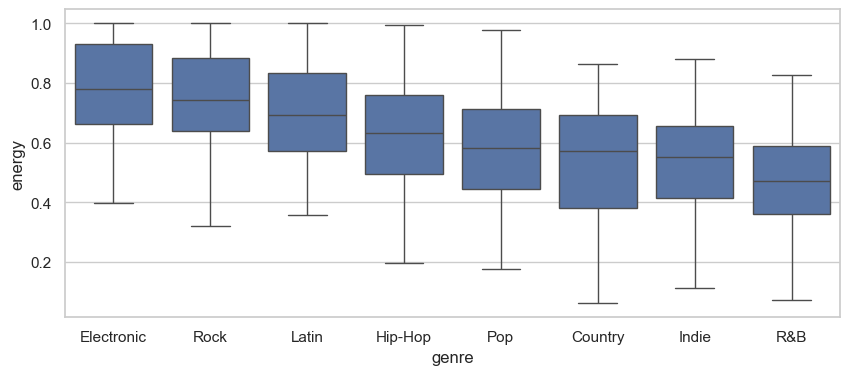

In [ ]:
fig, ax = plt.subplots(figsize=(10,4))
sns.boxplot(data=df,y="energy",x="genre", order=order,ax=ax)

In [42]:
len(df['label'].unique())

13

In [43]:
df.describe()

,year,duration_sec,tempo_bpm,energy,danceability,valence,acousticness,speechiness,loudness_db,streams_millions,monthly_listeners,playlist_adds,chart_peak
count,1200.000000,1200.000000,1200.00000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,398.000000
mean,2020.416667,208.478333,111.85000,0.630888,0.420776,0.490212,0.492011,0.162236,-7.632583,10.171200,547.436667,18006.349167,35.271357
std,2.572983,38.430439,24.02079,0.197475,0.185624,0.190506,0.199972,0.175026,3.440571,23.480756,1167.522745,41026.124735,42.904225
min,2015.000000,90.000000,60.00000,0.062000,0.000000,0.023000,0.000000,0.006000,-20.000000,0.050000,1.000000,50.000000,1.000000
25%,2018.000000,183.000000,89.00000,0.487000,0.291000,0.352000,0.354750,0.057000,-9.900000,1.740000,95.750000,2483.750000,9.000000
50%,2021.000000,208.000000,117.00000,0.641500,0.426000,0.498500,0.486500,0.101000,-7.600000,4.060000,223.000000,6641.500000,19.000000
75%,2023.000000,234.000000,131.00000,0.773250,0.545000,0.623250,0.630000,0.190500,-5.300000,10.330000,555.250000,17412.750000,43.000000
max,2024.000000,325.000000,165.00000,1.000000,1.000000,0.969000,1.000000,1.000000,-1.000000,523.170000,16655.000000,646358.000000,200.000000


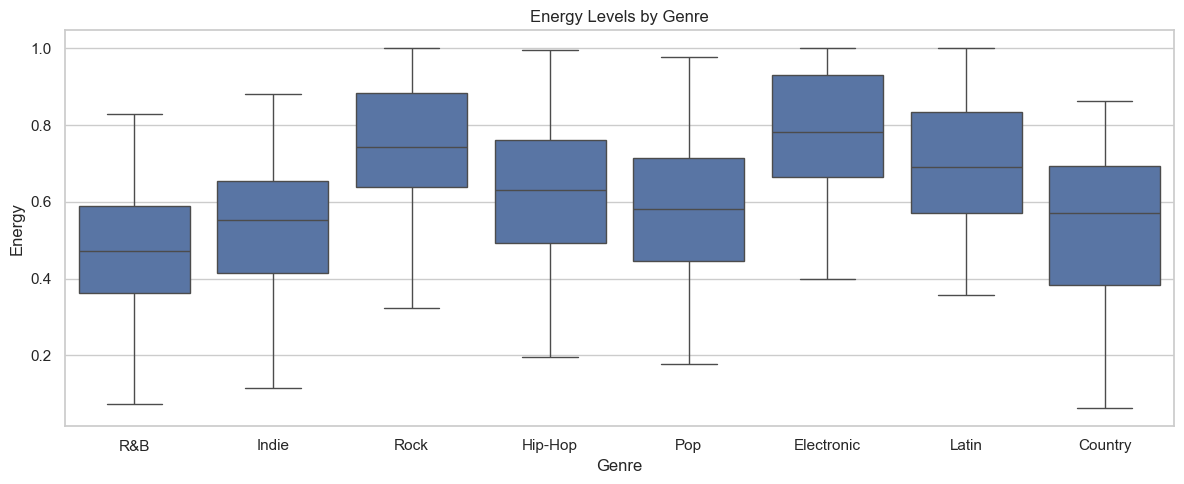

In [51]:
fig, ax = plt.subplots(figsize=(12,5))
sns.boxplot(data=df, y="energy", x="genre", ax=ax,)
ax.set_xlabel("Genre")
ax.set_ylabel("Energy")
ax.set_title("Energy Levels by Genre")
plt.tight_layout()
plt.show()

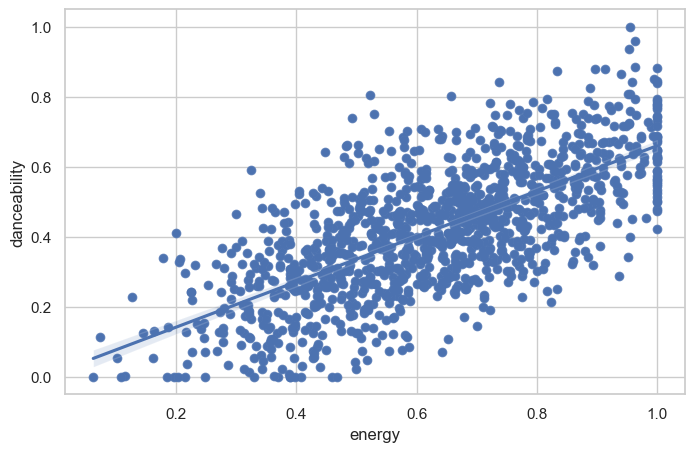

In [55]:
sample = df.sample(600)
fig, ax = plt.subplots(figsize=(8,5))
sns.scatterplot(data=df, x="energy", y="danceability")
sns.regplot(data=df, x="energy", y="danceability")
plt.show()

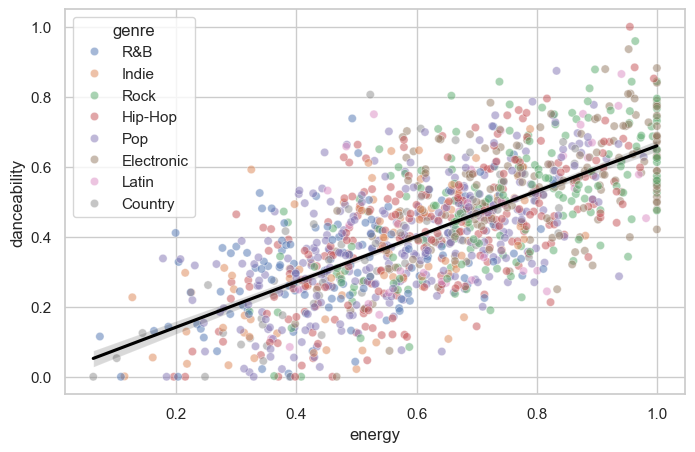

In [58]:
sample = df.sample(600)
fig, ax = plt.subplots(figsize=(8,5))
sns.scatterplot(data=df, x="energy", y="danceability", hue="genre", color="grey", alpha=0.5)
sns.regplot(data=df, x="energy", y="danceability", scatter=False, color="black")
plt.show()

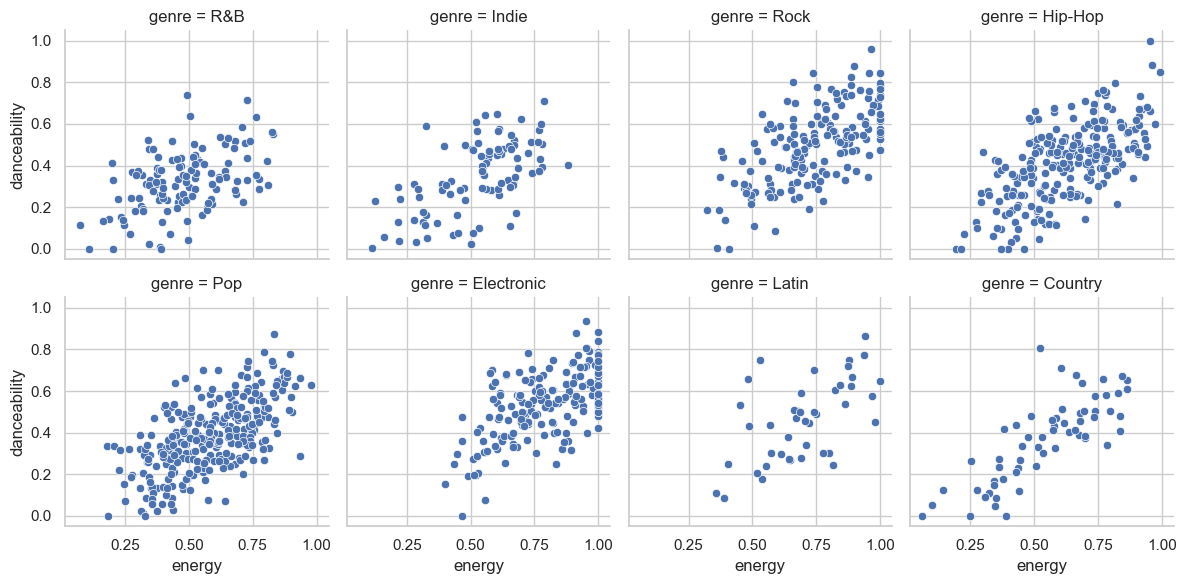

In [60]:
g = sns.FacetGrid(df, col="genre", col_wrap=4)
g.map(sns.scatterplot, "energy", "danceability")

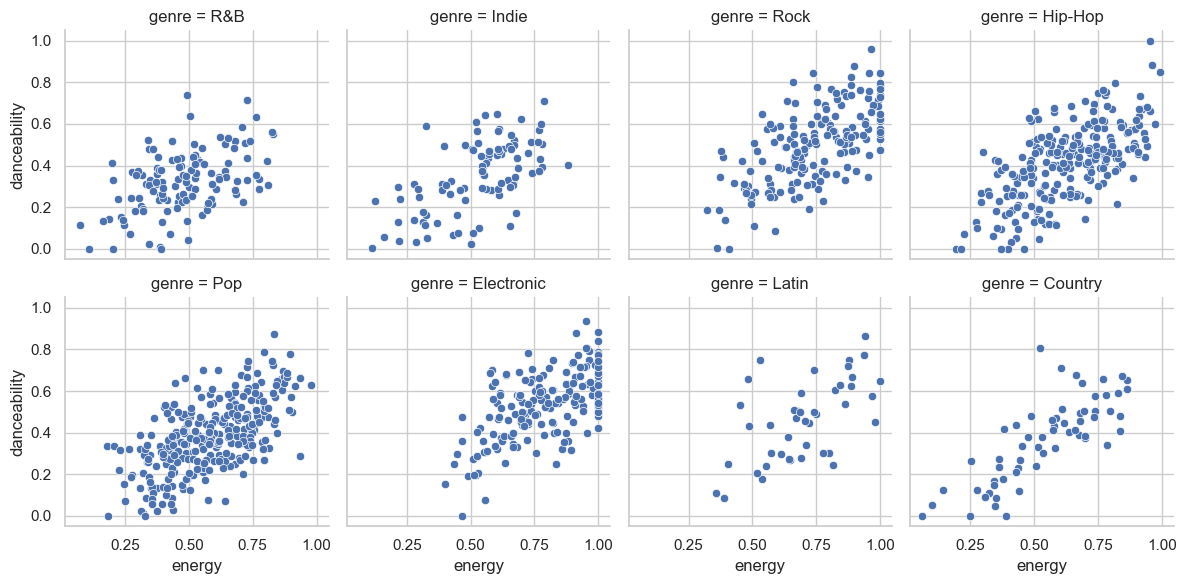

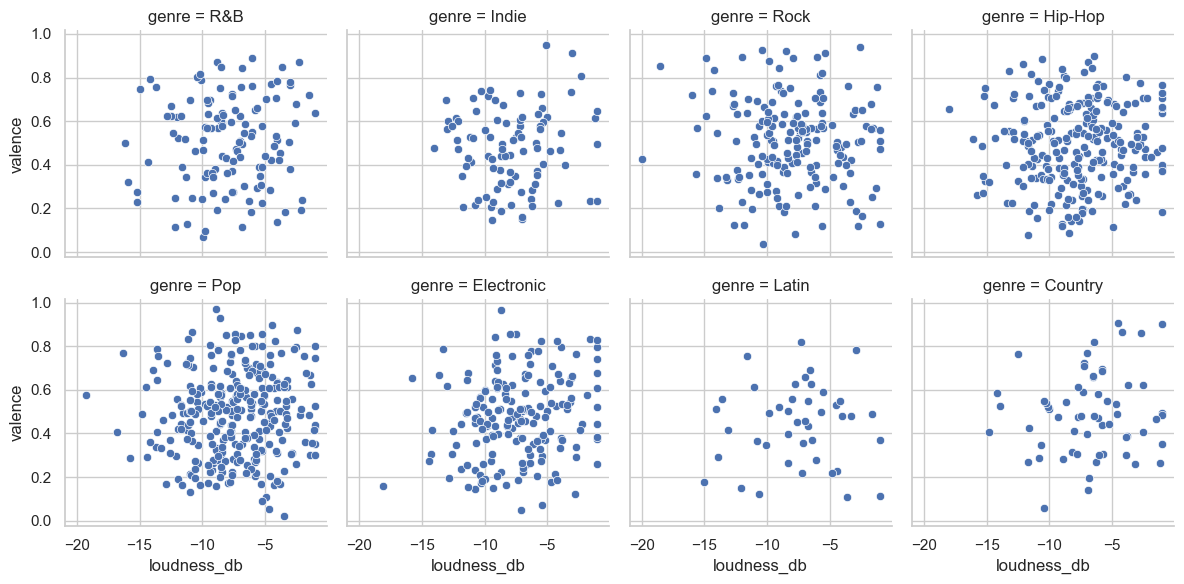

In [61]:
g = sns.FacetGrid(df, col="genre", col_wrap=4)
g.map(sns.scatterplot, "energy", "danceability")

g = sns.FacetGrid(df, col="genre", col_wrap=4)
g.map(sns.scatterplot, "loudness_db", "valence")

In [62]:
print(df[df["genre"] == "Pop"] [["year", "streams_millions"]])

      year  streams_millions
5     2023              1.44
11    2019              3.14
13    2024              1.08
21    2022              8.72
23    2021              2.66
...    ...               ...
1171  2021              3.92
1172  2022              7.22
1179  2022              0.38
1180  2022              3.85
1182  2021              2.85

[292 rows x 2 columns]


Text(0.5, 1.0, 'Pop Music Trend Over Time')

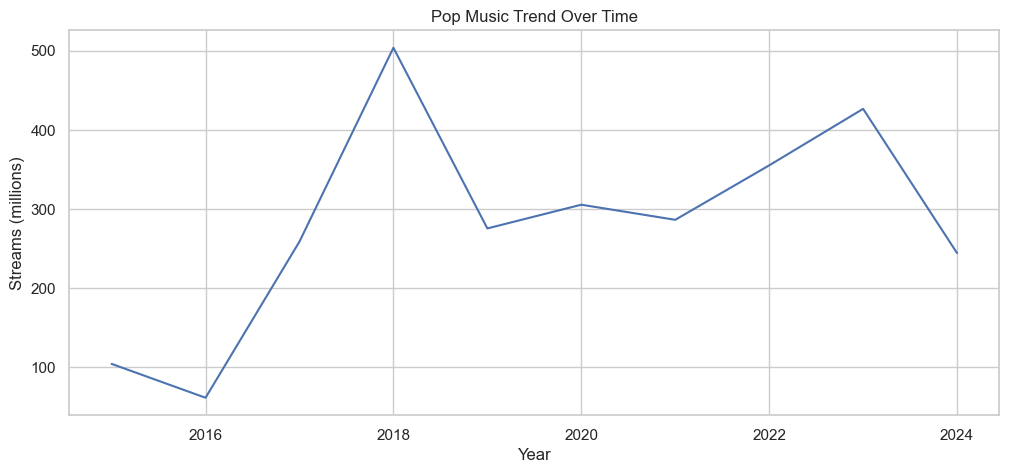

In [66]:
pop_trend = df[df["genre"] == "Pop"].groupby("year")["streams_millions"].sum().reset_index()
fig, ax = plt.subplots(figsize=(12,5))
ax.plot(pop_trend.year, pop_trend.streams_millions)
ax.set_xlabel("Year")
ax.set_ylabel("Streams (millions)")
ax.set_title("Pop Music Trend Over Time")

In [71]:
print(trend[["year", "genre", "streams_millions"]])

    year       genre  streams_millions
0   2015  Electronic             6.040
1   2015     Hip-Hop             5.755
2   2015       Indie            13.900
3   2015         Pop             7.160
4   2015         R&B             3.590
5   2015        Rock             4.800
6   2016  Electronic             5.520
7   2016     Hip-Hop             5.650
8   2016       Indie             3.720
9   2016         Pop             3.540
10  2016         R&B             5.840
11  2016        Rock             5.390
12  2017  Electronic             4.120
13  2017     Hip-Hop             4.660
14  2017       Indie             2.130
15  2017         Pop             3.560
16  2017         R&B             3.910
17  2017        Rock             5.150
18  2018  Electronic             4.180
19  2018     Hip-Hop             4.590
20  2018       Indie             6.385
21  2018         Pop            11.370
22  2018         R&B             5.520
23  2018        Rock             3.060
24  2019  Electronic     

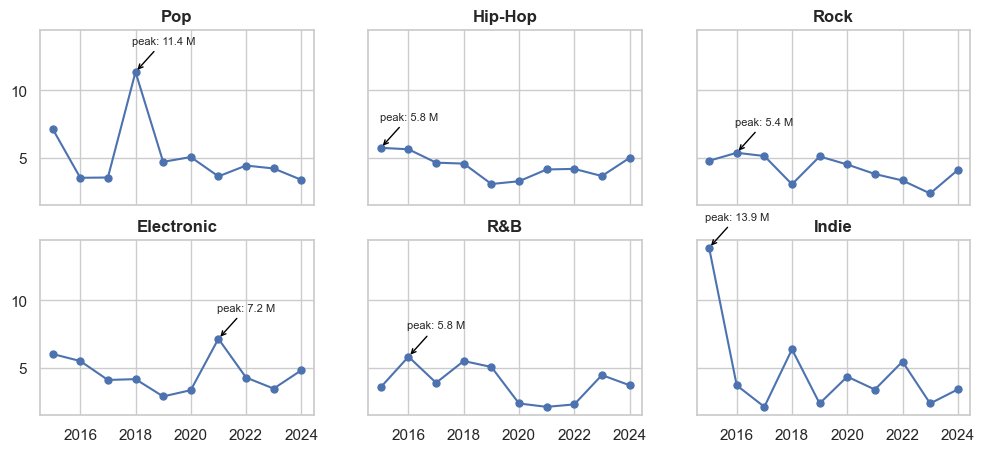

In [85]:
genres = ["Pop", "Hip-Hop", "Rock", "Electronic", "R&B", "Indie"]

trend = df[df.genre.isin(genres)].groupby(["year","genre"])["streams_millions"].median().reset_index()

fig, axes = plt.subplots(2,3,figsize=(12,5),sharex=True,sharey=True)
axes = axes.flatten()

for ax, genre in zip(axes, genres):
    subD = trend[trend.genre == genre]
    ax.plot(subD.year, subD.streams_millions,marker="o", ms=5)
    peak = subD.loc[subD.streams_millions.idxmax()]
    ax.annotate(f"peak: {peak.streams_millions:.1f} M",xy=(peak.year,peak.streams_millions), xytext=(20,20), textcoords='offset points',ha="center",fontsize=8, arrowprops=dict(arrowstyle="->",color="black",lw=1))
    ax.set_title(genre, fontweight="bold")

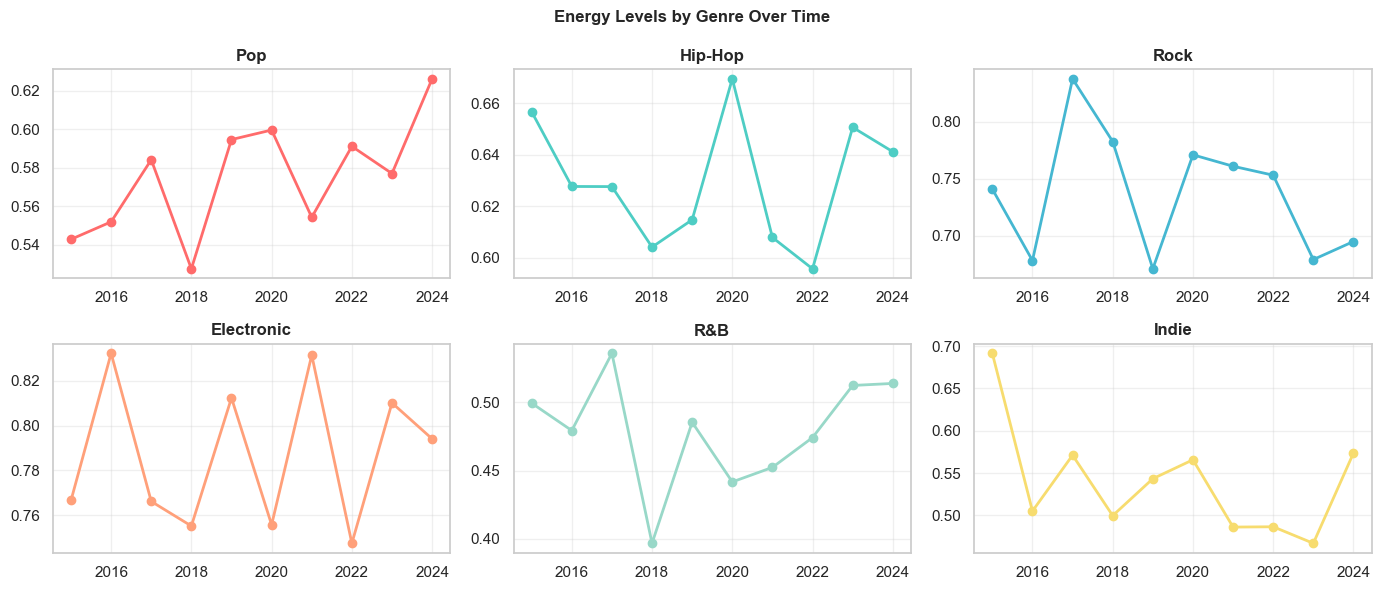

In [92]:
genres = ["Pop", "Hip-Hop", "Rock", "Electronic", "R&B", "Indie"]

trend = df[df.genre.isin(genres)].groupby(["year","genre"])["energy"].mean().reset_index()

fig, axes = plt.subplots(2,3,figsize=(14,6))

axes = axes.flatten()
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8', '#F7DC6F']

for ax, genre, color in zip(axes, genres, colors):
    subD = trend[trend.genre == genre]
    ax.plot(subD.year, subD.energy, marker="o", linewidth=2, color=color)
    ax.set_title(genre, fontweight="bold")
    ax.grid(True, alpha=0.3)

plt.suptitle("Energy Levels by Genre Over Time", fontsize=12, fontweight='bold')
plt.tight_layout()

In [101]:
import json
spec = {
  "$schema": "https://vega.github.io/schema/vega-lite/v6.json",
  "title": "Distribution of Energy by Genre",
  "width": 400,
  "height": 300,
  "data": {
    "values": json.loads(df.to_json(orient='records'))
  },
  "mark": "area",
  "transform": [
    {
      "density": "energy",
      "groupby": ["genre"],
      "extent": [0, 1]
    }
  ],
  "encoding": {
    "x": {"field": "value", "type": "quantitative", "title": "Energy"},
    "y": {"field": "density", "type": "quantitative", "stack": "zero"},
    "color": {"field": "genre", "type": "nominal"}
  }
}

chart.show()



alt.Chart(...)